step 0 | loss 0.5452 | acc 78.00%
step 5 | loss 0.2770 | acc 88.00%
step 10 | loss 0.2767 | acc 87.00%
step 15 | loss 0.2267 | acc 90.00%
step 20 | loss 0.1936 | acc 91.00%
step 25 | loss 0.1690 | acc 93.00%
step 30 | loss 0.1473 | acc 95.00%
step 35 | loss 0.1315 | acc 93.00%
step 40 | loss 0.1209 | acc 96.00%
step 45 | loss 0.1150 | acc 96.00%


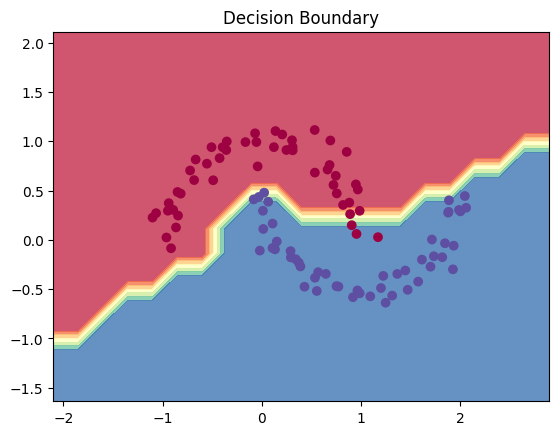

In [ ]:
import jax
import jax.numpy as jnp
from jax import grad, jit, random
from sklearn.datasets import make_moons
import numpy as np
import matplotlib.pyplot as plt

# -----------------------
# Data
# -----------------------
X, y = make_moons(n_samples=100, noise=0.1, random_state=0)
y = y * 2 - 1  # convert to -1 / +1

X = jnp.array(X)
y = jnp.array(y)
# -----------------------
# Model (MLP)
# -----------------------
def init_mlp(layer_sizes, key):
    params = []
    keys = random.split(key, len(layer_sizes) - 1)

    for i in range(len(layer_sizes) - 1):
        k = keys[i]
        in_dim = layer_sizes[i]
        out_dim = layer_sizes[i + 1]

        W = random.normal(k, (in_dim, out_dim)) * jnp.sqrt(2.0 / in_dim)
        b = jnp.zeros(out_dim)

        params.append((W, b))

    return params


def forward(params, x):
    for i, (W, b) in enumerate(params):
        x = jnp.dot(x, W) + b
        if i < len(params) - 1:
            x = jnp.tanh(x)
    return x.squeeze()


# -----------------------
# Loss (hinge loss like micrograd)
# -----------------------
def loss_fn(params, X, y):
    preds = jax.vmap(lambda x: forward(params, x))(X)

    # hinge loss
    losses = jnp.maximum(0, 1 - y * preds)
    data_loss = jnp.mean(losses)

    # L2 regularization
    reg = sum(jnp.sum(W**2) for W, _ in params)
    return data_loss + 1e-4 * reg


# -----------------------
# Accuracy
# -----------------------
def accuracy(params, X, y):
    preds = jax.vmap(lambda x: forward(params, x))(X)
    return jnp.mean((preds > 0) == (y > 0))


# -----------------------
# Training step
# -----------------------
@jit
def update(params, X, y, lr):
    grads = grad(loss_fn)(params, X, y)

    new_params = []
    for (W, b), (dW, db) in zip(params, grads):
        new_params.append((W - lr * dW, b - lr * db))

    return new_params


# -----------------------
# Train loop
# -----------------------
def train(params, X, y, steps=50):
    for i in range(steps):
        lr = 1.0 - 0.9 * i / steps
        params = update(params, X, y, lr)

        if i % 5 == 0:
            l = loss_fn(params, X, y)
            acc = accuracy(params, X, y)
            print(f"step {i} | loss {l:.4f} | acc {acc*100:.2f}%")

    return params


# -----------------------
# Decision boundary plot
# -----------------------
def plot_boundary(params, X, y):
    X_np = np.array(X)
    y_np = np.array(y)

    h = 0.25
    x_min, x_max = X_np[:, 0].min() - 1, X_np[:, 0].max() + 1
    y_min, y_max = X_np[:, 1].min() - 1, X_np[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, h),
        np.arange(y_min, y_max, h)
    )

    grid = jnp.array(np.c_[xx.ravel(), yy.ravel()])
    preds = jax.vmap(lambda x: forward(params, x))(grid)
    Z = np.array((preds > 0).astype(int)).reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.Spectral)
    plt.scatter(X_np[:, 0], X_np[:, 1], c=y_np, cmap=plt.cm.Spectral)
    plt.title("Decision Boundary")
    plt.show()


# -----------------------
# Run
# -----------------------
key = random.PRNGKey(0)
params = init_mlp([2, 16, 16, 1], key)

params = train(params, X, y, steps=50)
plot_boundary(params, X, y)